In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

In [2]:
df = pd.read_csv("studentDataset.csv")
df.head()

,Student_ID,Name,Age,Gender,Department,GPA,Attendance,Projects,Internship,Graduated
0,1,Student_1,24,Male,SE,3.70,76.0,0,No,No
1,2,Student_2,24,Male,DS,3.70,76.0,0,No,No
2,3,Student_3,22,Male,SE,2.90,50.0,3,Yes,No
3,4,Student_4,24,Male,DS,2.19,82.0,2,Yes,No
4,5,Student_5,20,Male,IT,3.14,100.0,5,No,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  50 non-null     int64  
 1   Name        50 non-null     object 
 2   Age         50 non-null     int64  
 3   Gender      50 non-null     object 
 4   Department  50 non-null     object 
 5   GPA         50 non-null     float64
 6   Attendance  47 non-null     float64
 7   Projects    50 non-null     int64  
 8   Internship  50 non-null     object 
 9   Graduated   50 non-null     object 
dtypes: float64(2), int64(3), object(5)
memory usage: 4.0+ KB


In [4]:
df["Attendance"].fillna(df["Attendance"].mean(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_12700\2072506671.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Attendance"].fillna(df["Attendance"].mean(), inplace=True)


In [5]:
df["Gender"].value_counts()

Gender
Female    31
Male      15
Fe         2
Ma         2
Name: count, dtype: int64

In [6]:
df["Department"].value_counts()

Department
CS    17
DS    14
SE    13
IT     6
Name: count, dtype: int64

In [7]:
df["Internship"].value_counts()

Internship
No     30
Yes    20
Name: count, dtype: int64

In [8]:
df["Graduated"].value_counts()  

Graduated
No     25
Yes    25
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  50 non-null     int64  
 1   Name        50 non-null     object 
 2   Age         50 non-null     int64  
 3   Gender      50 non-null     object 
 4   Department  50 non-null     object 
 5   GPA         50 non-null     float64
 6   Attendance  50 non-null     float64
 7   Projects    50 non-null     int64  
 8   Internship  50 non-null     object 
 9   Graduated   50 non-null     object 
dtypes: float64(2), int64(3), object(5)
memory usage: 4.0+ KB


In [10]:
df["Gender"] = df["Gender"].map({"Male": 0,"Ma": 0, "Female": 1,"Fe": 1})
df["Department"] = df["Department"].map({"CS": 0, "IT": 1, "SE": 2, "DS": 3})
df["Internship"] = df["Internship"].map({"No": 0, "Yes": 1})
df["Graduated"] = df["Graduated"].map({"No": 0, "Yes": 1})

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  50 non-null     int64  
 1   Name        50 non-null     object 
 2   Age         50 non-null     int64  
 3   Gender      50 non-null     int64  
 4   Department  50 non-null     int64  
 5   GPA         50 non-null     float64
 6   Attendance  50 non-null     float64
 7   Projects    50 non-null     int64  
 8   Internship  50 non-null     int64  
 9   Graduated   50 non-null     int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 4.0+ KB


In [12]:
df.head()

,Student_ID,Name,Age,Gender,Department,GPA,Attendance,Projects,Internship,Graduated
0,1,Student_1,24,0,2,3.70,76.0,0,0,0
1,2,Student_2,24,0,3,3.70,76.0,0,0,0
2,3,Student_3,22,0,2,2.90,50.0,3,1,0
3,4,Student_4,24,0,3,2.19,82.0,2,1,0
4,5,Student_5,20,0,1,3.14,100.0,5,0,1


<Axes: >

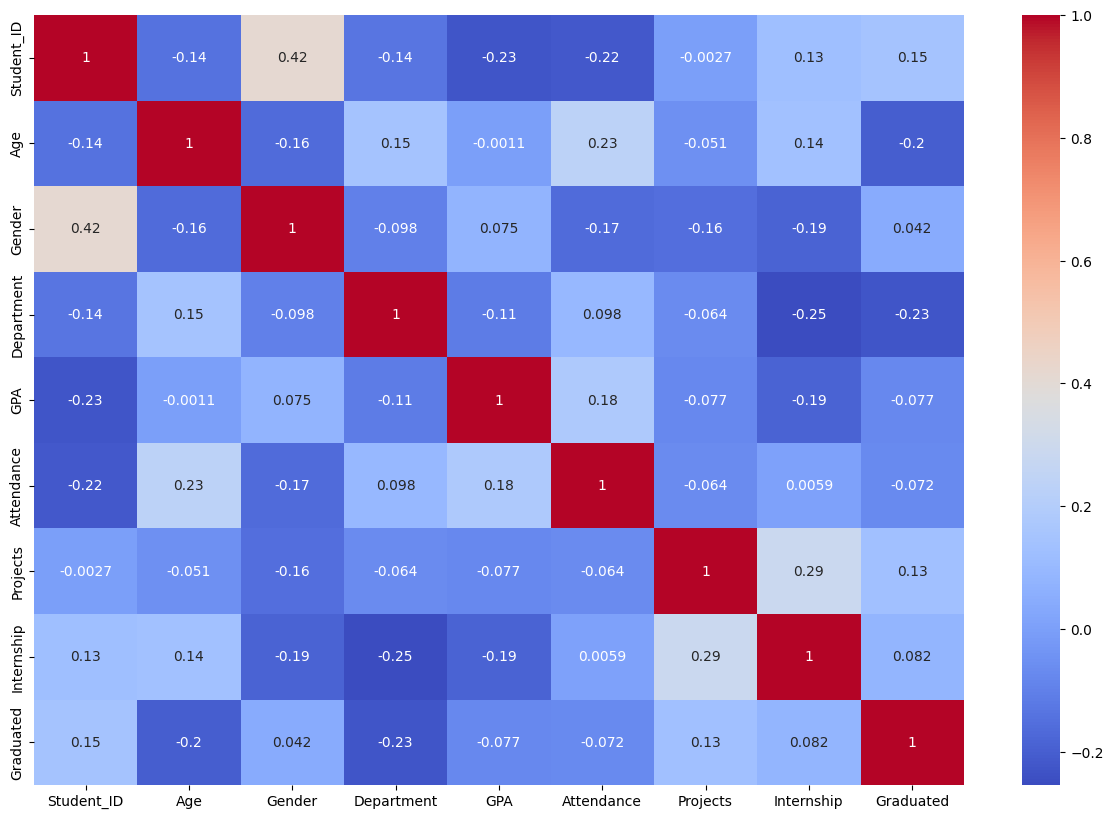

In [13]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [14]:
clustering = KMeans(n_clusters=5)
df["Cluster"] = clustering.fit_predict(df[["Gender", "Age","GPA","Department","Attendance","Projects","Internship","Graduated"]])
df.head()

,Student_ID,Name,Age,Gender,Department,GPA,Attendance,Projects,Internship,Graduated,Cluster
0,1,Student_1,24,0,2,3.70,76.0,0,0,0,2
1,2,Student_2,24,0,3,3.70,76.0,0,0,0,2
2,3,Student_3,22,0,2,2.90,50.0,3,1,0,0
3,4,Student_4,24,0,3,2.19,82.0,2,1,0,4
4,5,Student_5,20,0,1,3.14,100.0,5,0,1,1


In [15]:
df["Cluster"].value_counts()

Cluster
4    12
2    10
0    10
1    10
3     8
Name: count, dtype: int64

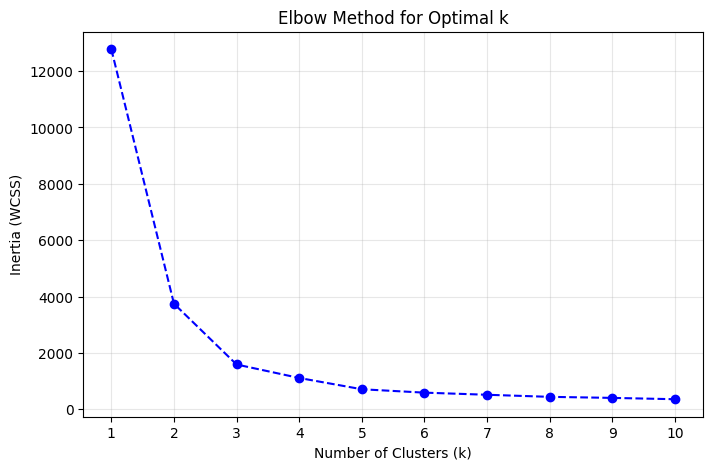

In [17]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Define the features to use
features = ["Gender", "Age", "GPA", "Department", "Attendance", "Projects", "Internship", "Graduated"]
X = df[features]

# 2. Calculate inertia for different values of k
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
clustering = KMeans(n_clusters=3)
df["Cluster"] = clustering.fit_predict(df[["Gender", "Age","GPA","Department","Attendance","Projects","Internship","Graduated"]])
centroids = clustering.cluster_centers_
print("Centroids:\n", centroids)

Centroids:
 [[ 0.77777778 21.83333333  3.24777778  1.38888889 76.67612293  2.05555556
   0.38888889  0.44444444]
 [ 0.64705882 20.52941176  2.73764706  1.35294118 56.17647059  2.17647059
   0.41176471  0.58823529]
 [ 0.53333333 21.66666667  3.00533333  1.73333333 93.4         1.6
   0.4         0.46666667]]


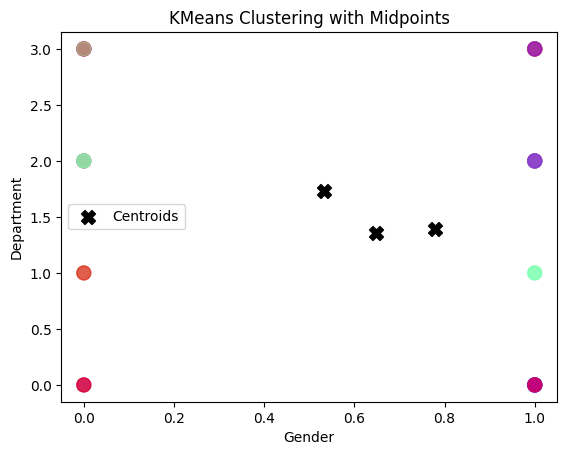

In [21]:
plt.scatter(df["Gender"], df["Department"], c=df["Cluster"], cmap='rainbow', alpha=0.5, s=100)
plt.scatter(centroids[:, 0], centroids[:, 3], c='black', s=100, marker='X', label='Centroids')
plt.title("KMeans Clustering with Midpoints")
plt.xlabel("Gender")
plt.ylabel("Department")
plt.legend()
plt.show()